In [1]:
import yt
import numpy as np
from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
import matplotlib.pyplot as plt

In [2]:
#file1 = "../Outputs/plt00650"
#file1 = "../Outputs/SplitRef/plt00153"
file1 = "../plt00002"
#file1 = "../plt00000"

ds = AMReXDataset(file1)

yt : [INFO     ] 2022-09-29 16:21:02,763 Parameters: current_time              = 0.1
yt : [INFO     ] 2022-09-29 16:21:02,764 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2022-09-29 16:21:02,765 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2022-09-29 16:21:02,767 Parameters: domain_right_edge         = [30. 30. 30.]


In [3]:
#avInit = ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
ad = ds.all_data()
#ad.max_level=0
ad.min_level=1
avE  = ad.quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
avG  = ad.quantities.weighted_average_quantity("Egrad", weight = ("index", "ones"))
avP  = ad.quantities.weighted_average_quantity("Epot", weight = ("index", "ones"))
avK  = ad.quantities.weighted_average_quantity("Ekin", weight = ("index", "ones"))


def _relField (field, data, name, av):
    return data[name]/av
def _relE(field,data):
    return _relField(field, data, "Edens", avE)
def _relEg(field,data):
    return _relField(field, data, "Egrad", avG)
def _relEp(field,data):
    return _relField(field, data, "Epot", avP)
def _relEk(field,data):
    return _relField(field, data, "Ekin", avK)
def _gPerE(field,data):
    #return data["Egrad"]/(data["Egrad"] + data["Epot"] + data["Ekin"])
    return data["Egrad"]/data["Edens"]
def _vPerE(field,data):
    return data["Epot"]/data["Edens"]
def _kPerE(field,data):
    return data["Ekin"]/data["Edens"]
def _check(field,data):
    return data["Edens"]/(data["Egrad"] + data["Epot"] + data["Ekin"])

ds.add_field(("boxlib","EdensRel"), function=_relE, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","EgradRel"), function=_relEg, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","EpotRel"), function=_relEp, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","EkinRel"), function=_relEk, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","GradPerE"), function=_gPerE, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","PotPerE"), function=_vPerE, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","KinPerE"), function=_kPerE, sampling_type="local", units="dimensionless", force_override=True)
ds.add_field(("boxlib","check"), function=_check, sampling_type="local", units="dimensionless", force_override=True)

In [4]:
print(avG)
ad = ds.all_data()
#ad.min_level=1
print(ad.quantities.weighted_average_quantity("Egrad", weight = ("index", "ones")))

2.7245646048643006e-06 dimensionless
2.7245646048643006e-06 dimensionless


In [5]:
ad = ds.all_data()
ad.max_level = 0
#mn, mx = ad.quantities.extrema("EdensRel")
mn, mx = ad.quantities.extrema("GradPerE")
ad = ds.all_data()
ad.min_level = 1
mn2, mx2 = ad.quantities.extrema("GradPerE")
print(mn/mn2)
print(mx/mx2)
print(mx)
print(mn)

0.6536140824083159 dimensionless
1.0008934630827215 dimensionless
0.10177404517557859 dimensionless
6.767842057302751e-08 dimensionless


yt : [INFO     ] 2022-09-29 16:21:50,721 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:50,722 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:50,723 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:50,724 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:50,725 Making a fixed resolution buffer of (('boxlib', 'EdensRel')) 800 by 800



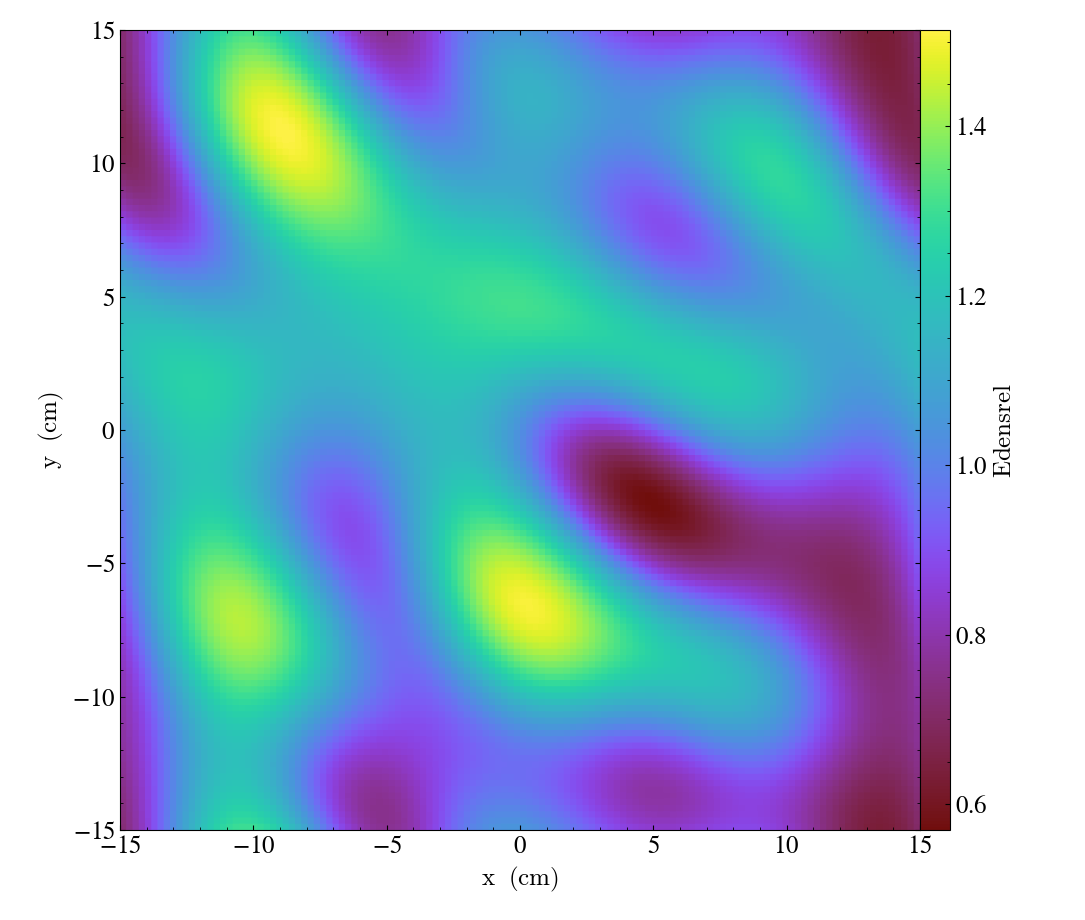

In [12]:
%matplotlib widget

ad = ds.all_data()
#ad.min_level=1
ad.max_level=0

slc = yt.SlicePlot(ds, "z", "EdensRel", data_source=ad)#, center = [0,0,0])
#slc = yt.SlicePlot(ds, "z", "check", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
slc.set_log("EdensRel", False)
#slc.set_log("check", False)

#slc.annotate_grids()
slc.show()

yt : [INFO     ] 2022-09-29 16:21:23,581 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:23,581 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:23,582 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:23,583 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:23,584 Making a fixed resolution buffer of (('boxlib', 'GradPerE')) 800 by 800



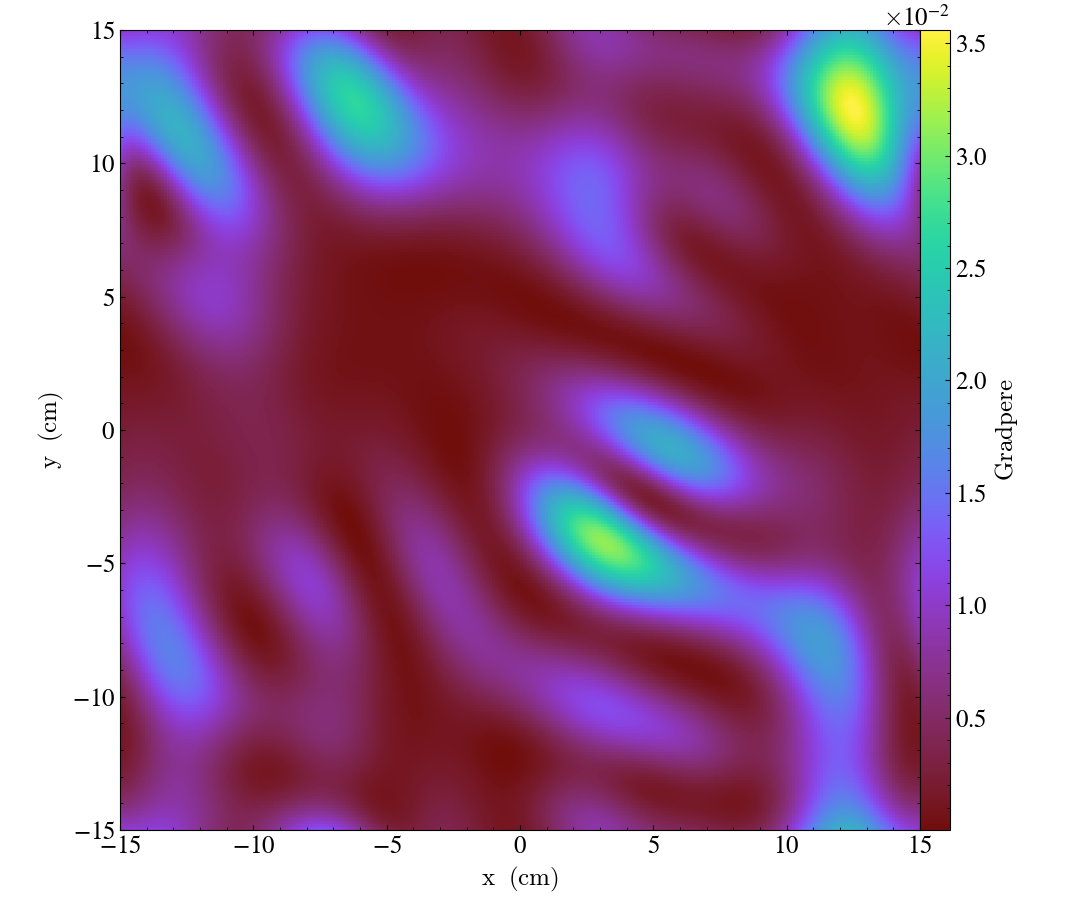

In [10]:
ad = ds.all_data()
ad.min_level=1
#ad.max_level=0

#slc = yt.SlicePlot(ds, "z", "EgradRel", data_source=ad)#, center = [0,0,0])
#slc = yt.SlicePlot(ds, "z", "Egrad", data_source=ad)#, center = [0,0,0])
slc = yt.SlicePlot(ds, "z", "GradPerE", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
#slc.set_log("EgradRel", False)
#slc.set_log("Egrad", False)
slc.set_log("GradPerE", False)

#slc.annotate_grids()
slc.show()

yt : [INFO     ] 2022-09-29 16:21:07,522 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:07,523 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:07,523 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:07,524 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:07,525 Making a fixed resolution buffer of (('boxlib', 'PotPerE')) 800 by 800



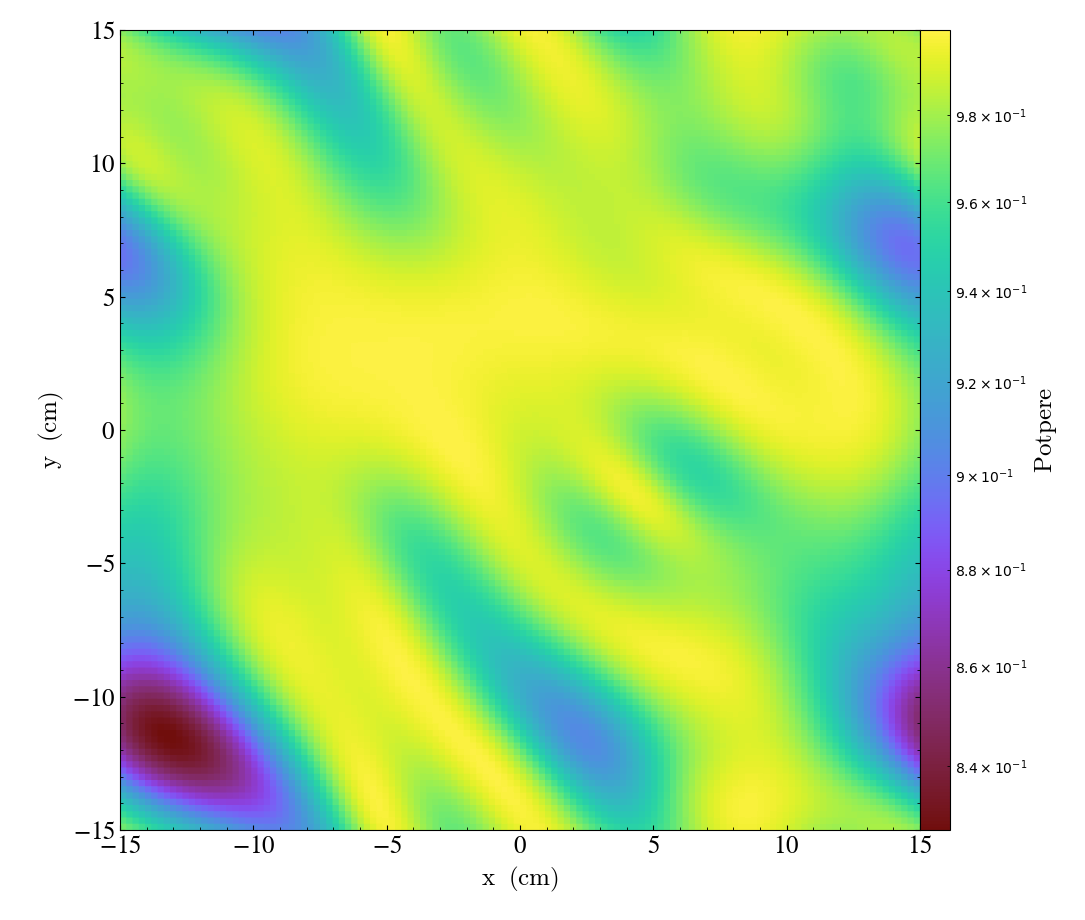

In [8]:
ad = ds.all_data()
#ad.min_level=1
ad.max_level=0

#slc = yt.SlicePlot(ds, "z", "EgradRel", data_source=ad)#, center = [0,0,0])
#slc = yt.SlicePlot(ds, "z", "Egrad", data_source=ad)#, center = [0,0,0])
slc = yt.SlicePlot(ds, "z", "PotPerE", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
#slc.set_log("EgradRel", False)
slc.set_log("Egrad", False)
#slc.set_log("PotPerE", False)

#slc.annotate_grids()
slc.show()

yt : [INFO     ] 2022-09-29 16:21:08,147 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:08,148 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:08,149 xlim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:08,150 ylim = 0.000000 30.000000
yt : [INFO     ] 2022-09-29 16:21:08,151 Making a fixed resolution buffer of (('boxlib', 'KinPerE')) 800 by 800



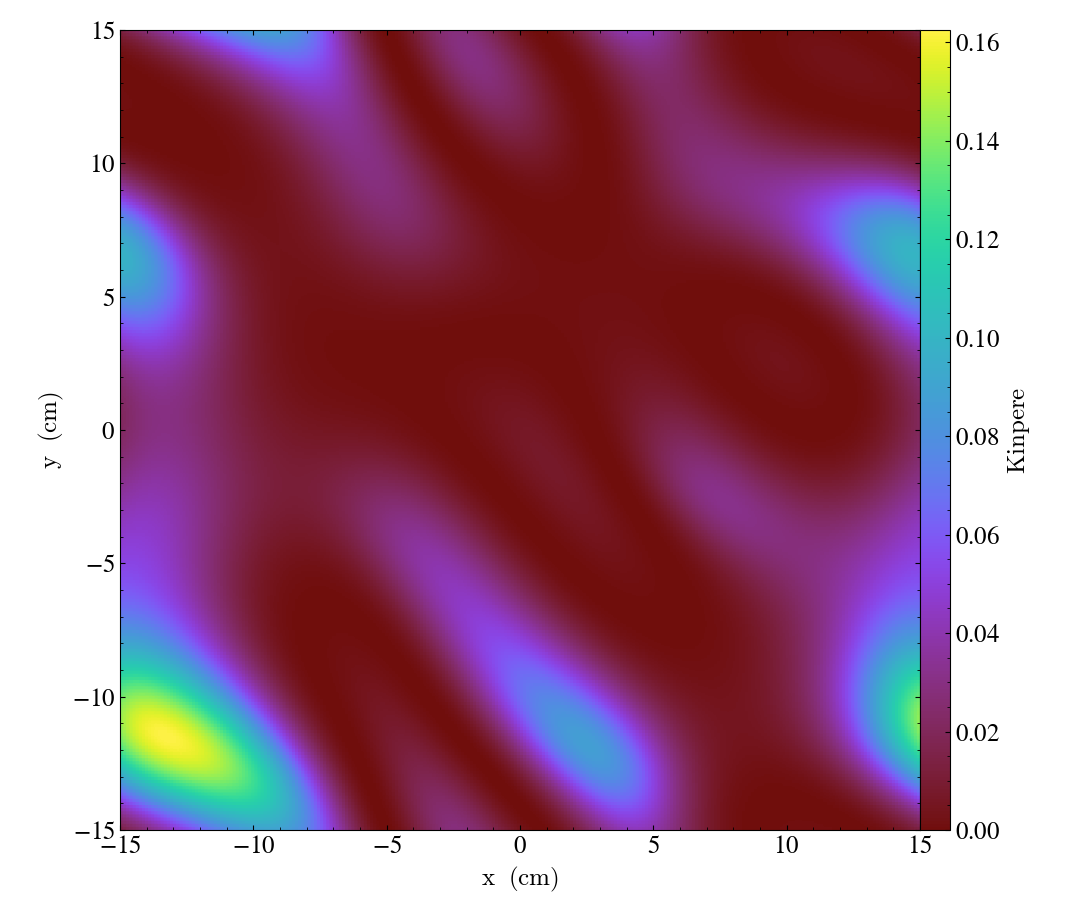

In [9]:
ad = ds.all_data()
ad.min_level=1
#ad.max_level=0

#slc = yt.SlicePlot(ds, "z", "EkinRel", data_source=ad)#, center = [0,0,0])
slc = yt.SlicePlot(ds, "z", "KinPerE", data_source=ad)#, center = [0,0,0])

slc.zoom(1)
#slc.set_log("EkinRel", False)
slc.set_log("KinPerE", False)

#slc.annotate_grids()
slc.show()